In [4]:
# Install required packages if not already installed
!pip install numpy matplotlib networkx scikit-learn



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random


In [6]:
class Vehicle:
    def __init__(self, vid, position):
        self.id = vid
        self.position = np.array(position)
        self.status = "normal"  # can be 'normal' or 'accident'
    
    def move(self):
        # Random small move to simulate driving
        dx, dy = np.random.uniform(-1, 1), np.random.uniform(-1, 1)
        self.position += np.array([dx, dy])


In [7]:
# Create 10 vehicles at random positions
vehicles = [Vehicle(vid=i, position=(random.randint(0, 100), random.randint(0, 100))) for i in range(10)]

# Check first vehicle
print(f"Vehicle ID: {vehicles[0].id}, Position: {vehicles[0].position}, Status: {vehicles[0].status}")


Vehicle ID: 0, Position: [2 5], Status: normal


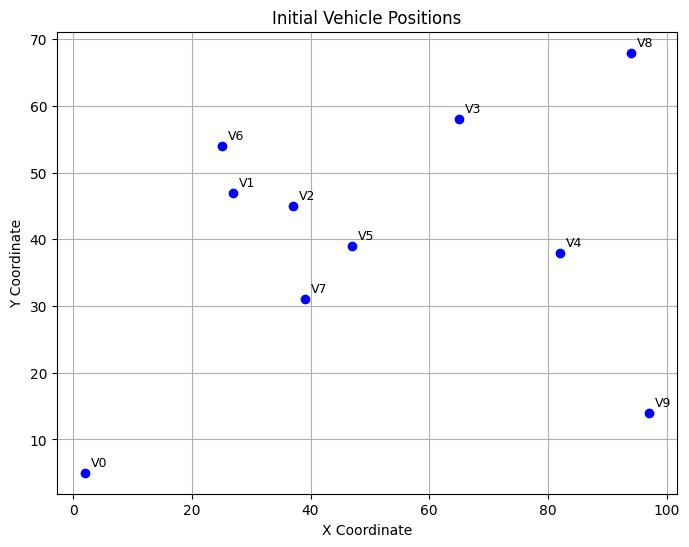

In [8]:
# Plot the initial positions
x = [v.position[0] for v in vehicles]
y = [v.position[1] for v in vehicles]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue')
for v in vehicles:
    plt.text(v.position[0]+1, v.position[1]+1, f"V{v.id}", fontsize=9)
plt.title('Initial Vehicle Positions')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()


Phase 2


Vehicle Class

In [ ]:
# import socket
# import threading
# import numpy as np

# class Vehicle:
#     def __init__(self, vid, position, port):
#         self.id = vid
#         self.position = np.array(position)
#         self.status = "normal"
#         self.port = port
#         self.socket = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
#         self.socket.bind(("localhost", self.port))
#         self.alert_received = False

#     def move(self):
#         dx, dy = np.random.uniform(-1, 1), np.random.uniform(-1, 1)
#         self.position += np.array([dx, dy])

#     def send_alert(self, target_port, message):
#         self.socket.sendto(message.encode(), ("localhost", target_port))

#     def receive_alerts(self, G, vehicles_dict):
#         while True:
#             try:
#                 data, addr = self.socket.recvfrom(1024)
#                 message = data.decode()
#                 print(f"🚗 Vehicle {self.id} received alert: {message}")

#                 if not self.alert_received:
#                     self.alert_received = True

#                     # Forward the alert to neighbors
#                     neighbors = list(G.neighbors(self.id))
#                     for neighbor_id in neighbors:
#                         neighbor_vehicle = vehicles_dict[neighbor_id]
#                         if not neighbor_vehicle.alert_received:
#                             self.send_alert(neighbor_vehicle.port, f"Alert forwarded by Vehicle {self.id}")
#             except Exception as e:
#                 print(f"Error in Vehicle {self.id}: {e}")


Create 10 Vehicles (each with random port)

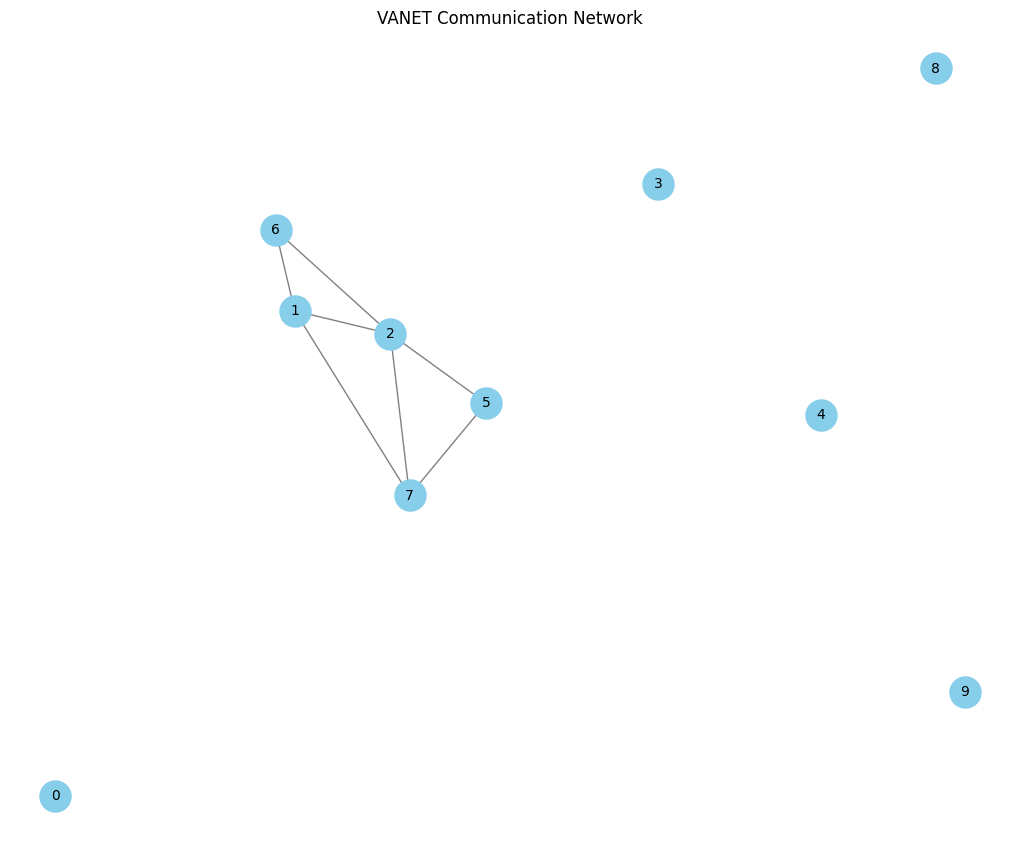

In [12]:
# Prepare positions for plotting
pos = {vehicle.id: vehicle.position for vehicle in vehicles}
import random

vehicles = []
ports = random.sample(range(10000, 11000), 10)  # Random ports

for i in range(10):
    v = Vehicle(i, (np.random.uniform(0, 100), np.random.uniform(0, 100)), ports[i])
    vehicles.append(v)

vehicles_dict = {v.id: v for v in vehicles}

# Plot the graph
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, font_size=10, edge_color='gray')
plt.title('VANET Communication Network')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid(True)
plt.show()


 Create a random network graph (connect vehicles)

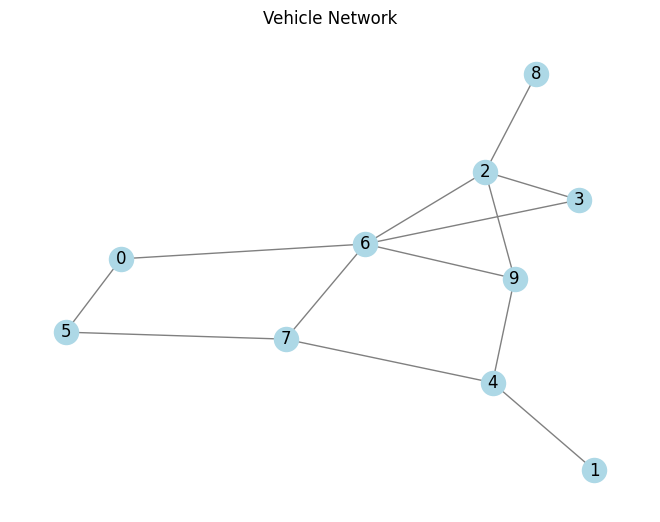

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.erdos_renyi_graph(n=10, p=0.3)  # 30% chance of connection between vehicles

# Draw the network
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Vehicle Network")
plt.show()


Start receiver threads for each vehicle

In [14]:
for v in vehicles:
    t = threading.Thread(target=v.receive_alerts, args=(G, vehicles_dict))
    t.daemon = True
    t.start()


🚗 Vehicle 2 received alert: Accident Alert from Vehicle 3
🚗 Vehicle 8 received alert: Alert forwarded by Vehicle 2
🚗 Vehicle 6 received alert: Accident Alert from Vehicle 3
🚗 Vehicle 9 received alert: Alert forwarded by Vehicle 2
🚗 Vehicle 0 received alert: Alert forwarded by Vehicle 6
🚗 Vehicle 7 received alert: Alert forwarded by Vehicle 6
🚗 Vehicle 6 received alert: Alert forwarded by Vehicle 2
🚗 Vehicle 4 received alert: Alert forwarded by Vehicle 9
🚗 Vehicle 4 received alert: Alert forwarded by Vehicle 7
🚗 Vehicle 5 received alert: Alert forwarded by Vehicle 0
🚗 Vehicle 5 received alert: Alert forwarded by Vehicle 7
🚗 Vehicle 1 received alert: Alert forwarded by Vehicle 4
🚗 Vehicle 1 received alert: Accident Alert from Vehicle 4
🚗 Vehicle 7 received alert: Accident Alert from Vehicle 4
🚗 Vehicle 9 received alert: Accident Alert from Vehicle 4


Accident Occurs: One vehicle broadcasts alert

In [17]:
# Randomly simulate accident
accident_vehicle = random.choice(vehicles)
accident_vehicle.status = "accident"
accident_vehicle.alert_received = True

print(f"\n🚨 Accident occurred at Vehicle {accident_vehicle.id} 🚨\n")

# Accident vehicle sends alerts to its neighbors
neighbors = list(G.neighbors(accident_vehicle.id))
for neighbor_id in neighbors:
    neighbor_vehicle = vehicles_dict[neighbor_id]
    accident_vehicle.send_alert(neighbor_vehicle.port, f"Accident Alert from Vehicle {accident_vehicle.id}")



🚨 Accident occurred at Vehicle 4 🚨



Step	Action	Meaning
1	Each vehicle has its own UDP socket (IP: localhost, random port).	Just like each real car has a communication device (DSRC/5G/other radio).
2	We created a network graph (using NetworkX)	This defines who is connected to whom (neighbors).
3	Each vehicle listens for incoming messages in parallel threads.	So when another vehicle sends an alert, it can catch and process it immediately.
4	When an accident happens, one vehicle sends real UDP packets to its neighbors.	Just like real accident alerts sent over VANETs!
5	Neighbor vehicles receive, print, and further relay the message	Only if they haven't received it before (to avoid rebroadcast storms).

phase 3

In [18]:
import math

def calculate_distance(x1, y1, x2, y2):
    """Calculate Euclidean distance between two points."""
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def extract_features(vehicle, accident_vehicle, all_vehicles, communication_range=300):
    """Extract features for ML model."""
    # Feature 1: Speed
    speed = vehicle.speed
    
    # Feature 2: Distance to accident vehicle
    distance = calculate_distance(vehicle.x, vehicle.y, accident_vehicle.x, accident_vehicle.y)
    
    # Feature 3: Number of neighbors within communication range
    neighbors = 0
    for other in all_vehicles:
        if other.id != vehicle.id:
            if calculate_distance(vehicle.x, vehicle.y, other.x, other.y) <= communication_range:
                neighbors += 1

    # Return features as list
    return [speed, distance, neighbors]


In [19]:
# Global list to store [features, label]
training_data = []


In [20]:
def on_receive_alert(vehicle, accident_vehicle, all_vehicles):
    """Handle receiving an alert."""
    features = extract_features(vehicle, accident_vehicle, all_vehicles)
    speed, distance, neighbors = features

    # Simple rule for temporary labeling
    if distance <= 300:
        label = 1  # Relay
    else:
        label = 0  # Do not relay

    # Save features and label
    training_data.append((features, label))

    # (Optional) Act based on rule (for now, we still forward alert according to rule)
    if label == 1:
        print(f"Vehicle {vehicle.id} relays the alert.")
        # Code to send alert to neighbors
    else:
        print(f"Vehicle {vehicle.id} does not relay the alert.")


In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

def train_ml_model(training_data):
    """Train ML model on collected training data."""
    # Separate features and labels
    X = np.array([item[0] for item in training_data])
    y = np.array([item[1] for item in training_data])

    # Split into training and testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train classifier
    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    # Evaluate model
    accuracy = model.score(X_test, y_test)
    print(f"Model trained! Test Accuracy: {accuracy*100:.2f}%")

    return model


In [22]:
def on_receive_alert_with_ml(vehicle, accident_vehicle, all_vehicles, model):
    """Handle receiving an alert using ML model."""
    features = extract_features(vehicle, accident_vehicle, all_vehicles)

    prediction = model.predict([features])[0]

    if prediction == 1:
        print(f"Vehicle {vehicle.id} (ML) relays the alert.")
        # Code to send alert to neighbors
    else:
        print(f"Vehicle {vehicle.id} (ML) does not relay the alert.")


phase 4

In [27]:
import math
import random

class Vehicle:
    def __init__(self, id, x, y, speed, direction):
        self.id = id
        self.x = x
        self.y = y
        self.speed = speed
        self.direction = direction

    def move(self):
        self.x += self.speed * math.cos(self.direction)
        self.y += self.speed * math.sin(self.direction)

def create_random_vehicles(num_vehicles):
    """Create a list of vehicles with random positions, speed, and direction."""
    vehicles = []
    for i in range(num_vehicles):
        x = random.uniform(0, 1000)  # Random position in a 1000x1000 area
        y = random.uniform(0, 1000)
        speed = random.uniform(10, 30)  # Random speed between 10 and 30 units
        direction = random.uniform(0, 2 * math.pi)  # Random direction (0 to 360 degrees)
        vehicle = Vehicle(i, x, y, speed, direction)
        vehicles.append(vehicle)
    return vehicles


In [28]:
import random

def choose_accident_vehicle(all_vehicles):
    """Randomly select a vehicle to simulate an accident."""
    accident_vehicle = random.choice(all_vehicles)
    print(f"Vehicle {accident_vehicle.id} is selected as the accident vehicle!")
    return accident_vehicle


In [29]:
def broadcast_alert(accident_vehicle, all_vehicles, model, communication_range=300):
    """Broadcast alert from accident vehicle and propagate using ML decisions."""
    queue = [accident_vehicle]  # Vehicles that need to broadcast

    already_alerted = set()  # Track vehicles who already received alert
    already_alerted.add(accident_vehicle.id)

    while queue:
        sender = queue.pop(0)
        
        # Find neighbors within range
        for vehicle in all_vehicles:
            if vehicle.id not in already_alerted:
                distance = calculate_distance(sender.x, sender.y, vehicle.x, vehicle.y)
                if distance <= communication_range:
                    already_alerted.add(vehicle.id)
                    
                    # Use ML to decide if this vehicle will relay
                    prediction = model.predict([extract_features(vehicle, accident_vehicle, all_vehicles)])[0]
                    
                    if prediction == 1:
                        print(f"Vehicle {vehicle.id} received and RELAYS the alert.")
                        queue.append(vehicle)  # This vehicle will now broadcast further
                    else:
                        print(f"Vehicle {vehicle.id} received but DOES NOT relay the alert.")


In [30]:
import time

def broadcast_alert_with_network_conditions(accident_vehicle, all_vehicles, model, communication_range=300):
    """Broadcast alert with simulated network latency and packet loss."""
    queue = [accident_vehicle]
    already_alerted = set()
    already_alerted.add(accident_vehicle.id)

    while queue:
        sender = queue.pop(0)
        
        for vehicle in all_vehicles:
            if vehicle.id not in already_alerted:
                distance = calculate_distance(sender.x, sender.y, vehicle.x, vehicle.y)
                if distance <= communication_range:
                    # Simulate packet loss (10% chance message is lost)
                    if random.random() < 0.1:
                        print(f"Vehicle {vehicle.id} lost the alert packet!")
                        continue

                    # Simulate network delay
                    time.sleep(random.uniform(0.05, 0.2))

                    already_alerted.add(vehicle.id)
                    
                    prediction = model.predict([extract_features(vehicle, accident_vehicle, all_vehicles)])[0]
                    
                    if prediction == 1:
                        print(f"Vehicle {vehicle.id} received and RELAYS the alert.")
                        queue.append(vehicle)
                    else:
                        print(f"Vehicle {vehicle.id} received but DOES NOT relay the alert.")


In [32]:
# 1. Create random vehicles
all_vehicles = create_random_vehicles(100)

# 2. Create dummy training data
training_data = [
    ([20, 50, 5], 1),
    ([15, 200, 1], 0),
    ([25, 30, 8], 1),
    ([10, 300, 0], 0),
    ([18, 60, 3], 1),
    ([12, 250, 2], 0),
]

# 3. Train your model
model = train_ml_model(training_data)

# 4. Choose accident vehicle
accident_vehicle = choose_accident_vehicle(all_vehicles)

# 5. Broadcast alert
broadcast_alert(accident_vehicle, all_vehicles, model)


Model trained! Test Accuracy: 100.00%
Vehicle 36 is selected as the accident vehicle!
Vehicle 4 received and RELAYS the alert.
Vehicle 5 received and RELAYS the alert.
Vehicle 8 received but DOES NOT relay the alert.
Vehicle 12 received and RELAYS the alert.
Vehicle 13 received and RELAYS the alert.
Vehicle 30 received and RELAYS the alert.
Vehicle 44 received and RELAYS the alert.
Vehicle 47 received but DOES NOT relay the alert.
Vehicle 50 received and RELAYS the alert.
Vehicle 59 received and RELAYS the alert.
Vehicle 60 received and RELAYS the alert.
Vehicle 62 received and RELAYS the alert.
Vehicle 69 received and RELAYS the alert.
Vehicle 72 received and RELAYS the alert.
Vehicle 74 received and RELAYS the alert.
Vehicle 83 received and RELAYS the alert.
Vehicle 89 received and RELAYS the alert.
Vehicle 90 received and RELAYS the alert.
Vehicle 93 received and RELAYS the alert.
Vehicle 94 received and RELAYS the alert.
Vehicle 96 received and RELAYS the alert.
Vehicle 7 received 

phase 5

In [33]:
import time

# Function to track number of hops and propagation time
def track_metrics(accident_vehicle, all_vehicles, model):
    # Track propagation start time
    start_time = time.time()
    
    # Variable to track hops (number of vehicles that relay the alert)
    num_hops = 0

    # Set to keep track of vehicles that have received the alert
    vehicles_visited = set()

    # Start with the accident vehicle
    vehicles_to_process = [accident_vehicle]
    
    while vehicles_to_process:
        current_vehicle = vehicles_to_process.pop(0)
        
        # If the vehicle has already relayed, skip it
        if current_vehicle.id in vehicles_visited:
            continue
        
        # Mark vehicle as visited
        vehicles_visited.add(current_vehicle.id)
        
        # Get the vehicle features (speed, distance, etc.)
        vehicle_features = [current_vehicle.speed, 
                            calculate_distance(accident_vehicle, current_vehicle),
                            len(get_neighbors(current_vehicle, all_vehicles))]
        
        # Predict relay decision
        should_relay = model.predict([vehicle_features])[0]
        
        if should_relay:
            num_hops += 1
            # Find neighboring vehicles within range and add to vehicles_to_process
            neighbors = get_neighbors(current_vehicle, all_vehicles)
            vehicles_to_process.extend(neighbors)
        
    # Track time taken for alert propagation
    end_time = time.time()
    propagation_time = end_time - start_time
    
    return num_hops, propagation_time

def calculate_distance(vehicle1, vehicle2):
    """Calculate the distance between two vehicles"""
    return math.sqrt((vehicle1.x - vehicle2.x)**2 + (vehicle1.y - vehicle2.y)**2)

def get_neighbors(vehicle, all_vehicles, max_distance=100):
    """Return a list of vehicles within a certain distance"""
    neighbors = []
    for other_vehicle in all_vehicles:
        if vehicle.id != other_vehicle.id and calculate_distance(vehicle, other_vehicle) <= max_distance:
            neighbors.append(other_vehicle)
    return neighbors


In [34]:
# Function for naive flooding
def naive_flooding(accident_vehicle, all_vehicles):
    # Track propagation start time
    start_time = time.time()
    
    # Variable to track hops
    num_hops = 0

    # Set to keep track of vehicles that have received the alert
    vehicles_visited = set()

    # Start with the accident vehicle
    vehicles_to_process = [accident_vehicle]
    
    while vehicles_to_process:
        current_vehicle = vehicles_to_process.pop(0)
        
        # If the vehicle has already relayed, skip it
        if current_vehicle.id in vehicles_visited:
            continue
        
        # Mark vehicle as visited
        vehicles_visited.add(current_vehicle.id)
        
        # Find neighboring vehicles within range and add to vehicles_to_process
        neighbors = get_neighbors(current_vehicle, all_vehicles)
        vehicles_to_process.extend(neighbors)
        
        num_hops += 1
    
    # Track time taken for alert propagation
    end_time = time.time()
    propagation_time = end_time - start_time
    
    return num_hops, propagation_time


In [35]:
# Choose an accident vehicle
accident_vehicle = choose_accident_vehicle(all_vehicles)

# Track metrics for ML-based approach
num_hops_ml, time_ml = track_metrics(accident_vehicle, all_vehicles, model)
print(f"ML-based model: Number of hops = {num_hops_ml}, Propagation time = {time_ml:.2f} seconds")

# Track metrics for Naive Flooding
num_hops_naive, time_naive = naive_flooding(accident_vehicle, all_vehicles)
print(f"Naive flooding: Number of hops = {num_hops_naive}, Propagation time = {time_naive:.2f} seconds")


Vehicle 75 is selected as the accident vehicle!
ML-based model: Number of hops = 6, Propagation time = 0.09 seconds
Naive flooding: Number of hops = 13, Propagation time = 0.00 seconds


In [36]:
# Function to calculate relay accuracy
def calculate_relay_accuracy(model, all_vehicles, accident_vehicle):
    correct_predictions = 0
    total_predictions = 0

    vehicles_to_process = [accident_vehicle]
    while vehicles_to_process:
        current_vehicle = vehicles_to_process.pop(0)

        # Get the vehicle features (speed, distance, etc.)
        vehicle_features = [current_vehicle.speed, 
                            calculate_distance(accident_vehicle, current_vehicle),
                            len(get_neighbors(current_vehicle, all_vehicles))]

        # Predict relay decision
        predicted_relay = model.predict([vehicle_features])[0]

        # Compare with actual relay decision (for example, assume the accident vehicle's neighbors should relay)
        actual_relay = 1 if len(get_neighbors(current_vehicle, all_vehicles)) > 0 else 0  # For demo purposes
        
        if predicted_relay == actual_relay:
            correct_predictions += 1
        
        total_predictions += 1

    accuracy = correct_predictions / total_predictions
    return accuracy

# Calculate relay accuracy
accuracy = calculate_relay_accuracy(model, all_vehicles, accident_vehicle)
print(f"Relay accuracy: {accuracy * 100:.2f}%")


Relay accuracy: 100.00%
